In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("ecom.csv")

In [3]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [4]:
df.shape

(250000, 13)

In [8]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='object')

In [9]:
df.isnull().sum()

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47596
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

In [12]:
df['Churn'].value_counts()

Churn
0    200126
1     49874
Name: count, dtype: int64

In [19]:
df.head()

,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [23]:
df =df.drop(columns = ['Purchase Date'])

In [24]:
df.head()

,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [25]:
df['Product Category'].unique()

array(['Electronics', 'Home', 'Clothing', 'Books'], dtype=object)

In [26]:
from sklearn.preprocessing import OneHotEncoder

In [33]:
OH = OneHotEncoder(sparse_output=False, drop='first')

In [34]:
product_category_encoded = OH.fit_transform(df[['Product Category']])


encoded_col_names = OH.get_feature_names_out(['Product Category'])


product_category_df = pd.DataFrame(product_category_encoded, columns=encoded_col_names)
product_category_df.index = df.index


df = df.drop('Product Category', axis=1)
df = pd.concat([df, product_category_df], axis=1)

In [35]:
df.head()

,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn,Product Category_Clothing,Product Category_Electronics,Product Category_Home
0,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0,0.0,1.0,0.0
1,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0,0.0,0.0,1.0
2,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0,0.0,0.0,1.0
3,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0,1.0,0.0,0.0
4,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1,0.0,0.0,1.0


In [36]:
df['Payment Method'].unique()

array(['Credit Card', 'PayPal', 'Cash', 'Crypto'], dtype=object)

In [37]:
payment_encoded = OH.fit_transform(df[['Payment Method']])


encoded_col_names = OH.get_feature_names_out(['Payment Method'])


payment_df = pd.DataFrame(payment_encoded, columns=encoded_col_names)
payment_df.index = df.index


df = df.drop('Payment Method', axis=1)
df = pd.concat([df, product_category_df], axis=1)

In [38]:
df.head()

,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Customer Name,Age,Gender,Churn,Product Category_Clothing,Product Category_Electronics,Product Category_Home,Product Category_Clothing,Product Category_Electronics,Product Category_Home
0,12,3,740,37,0.0,Christine Hernandez,37,Male,0,0.0,1.0,0.0,0.0,1.0,0.0
1,468,4,2739,37,0.0,Christine Hernandez,37,Male,0,0.0,0.0,1.0,0.0,0.0,1.0
2,288,2,3196,37,0.0,Christine Hernandez,37,Male,0,0.0,0.0,1.0,0.0,0.0,1.0
3,196,1,3509,37,0.0,Christine Hernandez,37,Male,0,1.0,0.0,0.0,1.0,0.0,0.0
4,449,1,3452,49,0.0,James Grant,49,Female,1,0.0,0.0,1.0,0.0,0.0,1.0


In [40]:
df =df.drop(columns = ['Customer Name'])

In [41]:
df.head()


,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Gender,Churn,Product Category_Clothing,Product Category_Electronics,Product Category_Home,Product Category_Clothing,Product Category_Electronics,Product Category_Home
0,12,3,740,37,0.0,37,Male,0,0.0,1.0,0.0,0.0,1.0,0.0
1,468,4,2739,37,0.0,37,Male,0,0.0,0.0,1.0,0.0,0.0,1.0
2,288,2,3196,37,0.0,37,Male,0,0.0,0.0,1.0,0.0,0.0,1.0
3,196,1,3509,37,0.0,37,Male,0,1.0,0.0,0.0,1.0,0.0,0.0
4,449,1,3452,49,0.0,49,Female,1,0.0,0.0,1.0,0.0,0.0,1.0


In [42]:
df['Returns'] = df['Returns'].fillna(value = 0)

In [43]:
df.isnull().sum()

Product Price                   0
Quantity                        0
Total Purchase Amount           0
Customer Age                    0
Returns                         0
Age                             0
Gender                          0
Churn                           0
Product Category_Clothing       0
Product Category_Electronics    0
Product Category_Home           0
Product Category_Clothing       0
Product Category_Electronics    0
Product Category_Home           0
dtype: int64

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 14 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   Product Price                 250000 non-null  int64  
 1   Quantity                      250000 non-null  int64  
 2   Total Purchase Amount         250000 non-null  int64  
 3   Customer Age                  250000 non-null  int64  
 4   Returns                       250000 non-null  float64
 5   Age                           250000 non-null  int64  
 6   Gender                        250000 non-null  object 
 7   Churn                         250000 non-null  int64  
 8   Product Category_Clothing     250000 non-null  float64
 9   Product Category_Electronics  250000 non-null  float64
 10  Product Category_Home         250000 non-null  float64
 11  Product Category_Clothing     250000 non-null  float64
 12  Product Category_Electronics  250000 non-nul

In [49]:
df.describe()

,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn,Product Category_Clothing,Product Category_Electronics,Product Category_Home,Product Category_Clothing,Product Category_Electronics,Product Category_Home
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,254.659512,2.998896,2725.370732,43.940528,0.403076,43.940528,0.199496,0.300208,0.200740,0.199404,0.300208,0.200740,0.199404
std,141.568577,1.414694,1442.933565,15.350246,0.490517,15.350246,0.399622,0.458349,0.400555,0.399553,0.458349,0.400555,0.399553
min,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,132.000000,2.000000,1477.000000,31.000000,0.000000,31.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,255.000000,3.000000,2724.000000,44.000000,0.000000,44.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,377.000000,4.000000,3974.000000,57.000000,1.000000,57.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [50]:
df.head(2)

,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Gender,Churn,Product Category_Clothing,Product Category_Electronics,Product Category_Home,Product Category_Clothing,Product Category_Electronics,Product Category_Home
0,12,3,740,37,0.0,37,Male,0,0.0,1.0,0.0,0.0,1.0,0.0
1,468,4,2739,37,0.0,37,Male,0,0.0,0.0,1.0,0.0,0.0,1.0


In [51]:
#Age vs churn graph : 0 : (active users ) , 1 -> non active user

/var/folders/l5/l6v813mx703gx2qrmjnnzdh40000gn/T/ipykernel_33416/3999335427.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_churn_counts = df.groupby(['age_group', 'Churn']).size().unstack(fill_value=0)


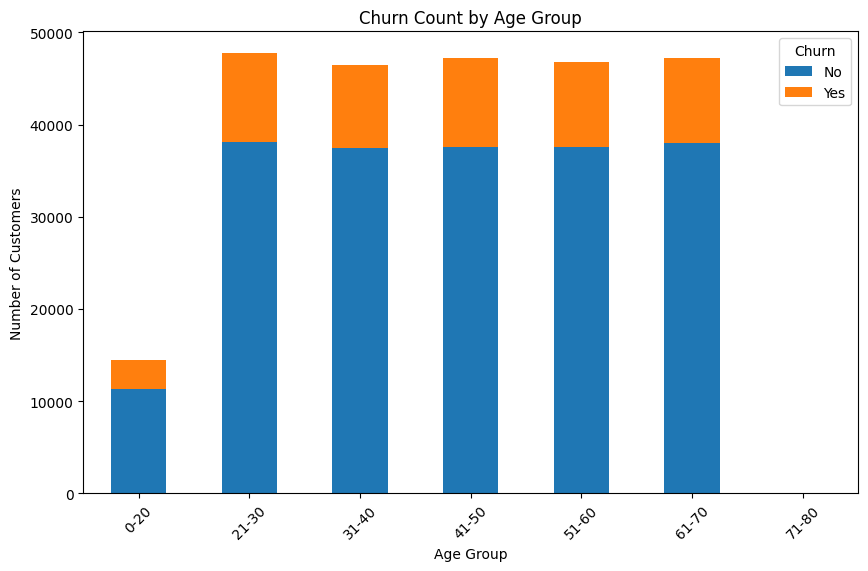

In [55]:
import matplotlib.pyplot as plt
import pandas as pd

# Create age bins
bins = [0, 20, 30, 40, 50, 60, 70, 80]
labels = ['0-20','21-30','31-40','41-50','51-60','61-70','71-80']

df['age_group'] = pd.cut(df['Age'], bins=bins, labels=labels)

# Count churn per age group
age_churn_counts = df.groupby(['age_group', 'Churn']).size().unstack(fill_value=0)

# Plot stacked bar chart
age_churn_counts.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Churn Count by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
plt.legend(title='Churn', labels=['No', 'Yes'])
plt.show()

In [56]:
##Seems like many people are still users or purchasing ones

In [58]:
X = df.drop(columns = ['Churn'])

In [59]:
X.head(2)

,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Gender,Product Category_Clothing,Product Category_Electronics,Product Category_Home,Product Category_Clothing,Product Category_Electronics,Product Category_Home,age_group
0,12,3,740,37,0.0,37,Male,0.0,1.0,0.0,0.0,1.0,0.0,31-40
1,468,4,2739,37,0.0,37,Male,0.0,0.0,1.0,0.0,0.0,1.0,31-40


In [60]:
y = df['Churn']

In [61]:
y.head(2)

0    0
1    0
Name: Churn, dtype: int64

In [63]:
df.columns


Index(['Product Price', 'Quantity', 'Total Purchase Amount', 'Customer Age',
       'Returns', 'Age', 'Gender', 'Churn', 'Product Category_Clothing',
       'Product Category_Electronics', 'Product Category_Home',
       'Product Category_Clothing', 'Product Category_Electronics',
       'Product Category_Home', 'age_group'],
      dtype='object')

In [66]:
from sklearn.model_selection import train_test_split

# X_train , X_test , y_train, y_test = train_test_split(X,y , 

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [68]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train, y_train)

ValueError: could not convert string to float: 'Male'

In [69]:
X = pd.get_dummies(X, columns=['Gender'], drop_first=True)

In [70]:
print(X.dtypes)

Product Price                      int64
Quantity                           int64
Total Purchase Amount              int64
Customer Age                       int64
Returns                          float64
Age                                int64
Product Category_Clothing        float64
Product Category_Electronics     float64
Product Category_Home            float64
Product Category_Clothing        float64
Product Category_Electronics     float64
Product Category_Home            float64
age_group                       category
Gender_Male                         bool
dtype: object


In [71]:
X = X.drop('age_group', axis=1)

In [72]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [73]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score


y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:,1]

In [74]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[20296 19729]
 [ 5006  4969]]


In [75]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.51      0.62     40025
           1       0.20      0.50      0.29      9975

    accuracy                           0.51     50000
   macro avg       0.50      0.50      0.45     50000
weighted avg       0.68      0.51      0.55     50000



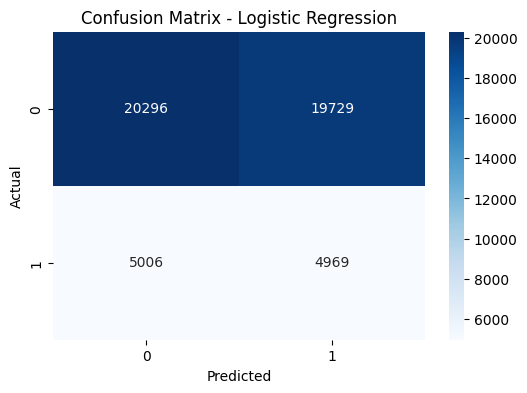

In [76]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()